<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="400" height="600" /> 
    
    
## <font color='navy'> PROYECTO 03 - Final
    
### <font color='navy'> Laboratorio de Aprendizaje Estadistico

    Guillermo Casillas Copca
    Francisco Josué Ramirez Avila
    Juan Alvaro Morales Ramirez Valadez
    

<div style="background-color: #cce5ff; padding: 15px; border-radius: 8px;">
  <h3> Objetivo</h3>
</div>


## **Objetivo General**
>Analizar y predecir el precio de vehículos Toyota en el mercado de autos usados utilizando modelos de regresión basados en Random Forest y XGBoost, con el fin de identificar los factores que influyen de manera significativa en el valor de los autos. 

---

## **Objetivos Específicos**
>1. **Preparar el dataset:** depurar y organizar las variables relevantes para el análisis.  
2. **Definir la estructura del modelo:** establecer el precio como variable objetivo y seleccionar los predictores.  
3. **Preprocesar los datos:** codificar variables, tratar valores atípicos y dividir en entrenamiento y prueba.  
4. **Entrenar un modelo Random Forest:** construir el modelo de regresión con semilla fija y evaluar su desempeño.  
5. **Entrenar un modelo XGBoost:** implementar el modelo con semilla fija y medir su capacidad predictiva.  
6. **Comparar ambos modelos:** analizar métricas como RMSE, MAE y 𝑅^2 para determinar el mejor desempeño. 
7. **Interpretar resultados:** identificar las variables más influyentes en la predicción del precio.

<div style="background-color: #cce5ff; padding: 15px; border-radius: 8px;">
  <h3> Marco Teórico</h3>
</div>


## **Regresión Lineal**
La regresión lineal es un método estadístico utilizado para modelar la relación entre una variable dependiente continua y una o más variables independientes.

---

## **6 problemas potenciales en una regresión (ISLP)**
1. **No linealidad entre la respuesta y los predictores**  
   La relación real entre X e Y no es una línea recta. La recta del modelo no captura bien la forma real de los datos, por eso predice mal.

2. **Correlación de los errores**  
   Los errores no son independientes; están relacionados entre sí.  
   **Ejemplo:** si un error es grande, el siguiente también tiende a serlo. Esto hace que las estimaciones sean menos confiables.

3. **Varianza no constante de los errores (heterocedasticidad)**  
   Los errores no tienen la misma dispersión en todos los valores de X. A veces están muy separados, a veces muy juntos. Esto afecta la precisión de la regresión.

4. **Outliers**  
   Son puntos de datos muy fuera de lo común. No siguen el patrón general y pueden distorsionar la recta si son extremos.

5. **Puntos de alta palanca (high leverage)**  
   Son puntos con valores de X muy diferentes a los demás. Aunque su Y no sea extraña, por estar en un lugar “raro” de X pueden arrastrar la recta hacia ellos.

6. **Colinealidad**  
   Dos o más variables predictoras están muy relacionadas entre sí. El modelo no sabe cuál está explicando realmente Y, y las estimaciones se vuelven inestables.



---
## **Árboles para Regresión**
Los árboles de regresión dividen el espacio de predicción en regiones basadas en umbrales de las variables independientes.
En cada región, se asigna un valor promedio del objetivo.

Características clave:
- Modelo flexible que captura relaciones no lineales.
- Fácil interpretación mediante reglas tipo “si-entonces”.
- Sensibles a pequeñas variaciones en los datos.

---

## **Árboles para Clasificación**
Un árbol de clasificación separa los datos en regiones homogéneas respecto a la clase objetivo.

Características:
- Utiliza métricas como Gini o entropía para decidir las divisiones.
- Permite visualizar rutas de decisión claras.
- Adecuado para datos mixtos (categóricos y numéricos).

---

## **Bootstrap**
El bootstrap es una técnica de remuestreo donde se generan múltiples muestras con reemplazo a partir del conjunto original.

Permite:
- Estimar la variabilidad de un modelo.
- Evaluar la estabilidad de métricas como coeficientes o precisión.
- Construir intervalos de confianza sin depender de supuestos fuertes.

---

## **Ensambles de Modelos**
Los métodos de ensamble combinan múltiples modelos para mejorar la estabilidad y el rendimiento predictivo.

Ventaja central:
- La combinación reduce la varianza y/o el sesgo, dependiendo del método.

---

## **Bagging (Bootstrap + Aggregating)**
Bagging consiste en entrenar muchos modelos independientes sobre diferentes muestras bootstrap y luego promediar (regresión) o votar (clasificación).

Propósito: reducir la varianza del modelo base.

Ejemplo típico: árboles de decisión → Random Forest.

---

## **Boosting**
Boosting entrena modelos de manera secuencial, donde cada nuevo modelo intenta corregir los errores del anterior.

Características:
- Genera modelos fuertes a partir de modelos débiles.
- Pone más peso en observaciones mal clasificadas.

---

## **Tema Elegido para el Proyecto**
Predicción del precio de vehículos Toyota en el mercado de autos usados a partir de sus características técnicas y atributos generales, utilizando modelos de regresión basados en Random Forest y XGBoost.

<div style="background-color: #cce5ff; padding: 15px; border-radius: 8px;">
  <h3> Análisis de Dataset</h3>
</div>


In [1]:
import pandas as pd

df = pd.read_csv("toyota.csv")
df = df.drop_duplicates().dropna()

df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6699 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6699 non-null   object 
 1   year          6699 non-null   int64  
 2   price         6699 non-null   int64  
 3   transmission  6699 non-null   object 
 4   mileage       6699 non-null   int64  
 5   fuelType      6699 non-null   object 
 6   tax           6699 non-null   int64  
 7   mpg           6699 non-null   float64
 8   engineSize    6699 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 523.4+ KB


In [3]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,6699.000000,6699.000000,6699.000000,6699.000000,6699.000000,6699.000000
mean,2016.742797,12529.799074,22889.588745,94.549933,63.078728,1.471996
std,2.205271,6358.562625,19109.288501,73.942649,15.861037,0.435624
min,1998.000000,850.000000,2.000000,0.000000,2.800000,0.000000
25%,2016.000000,8266.500000,9488.500000,0.000000,55.400000,1.000000
50%,2017.000000,10798.000000,18571.000000,135.000000,62.800000,1.500000
75%,2018.000000,14995.000000,31059.500000,145.000000,70.600000,1.800000
max,2020.000000,59995.000000,174419.000000,565.000000,235.000000,4.500000


In [4]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [5]:
len(df)

6699

# Análisis del Dataset: *Toyota Used Cars Market Insights (Kaggle)*


## **¿De dónde viene?**
>El dataset proviene de la plataforma Kaggle, dentro del repositorio “Toyota Used Car Market Insights”, creado y publicado por Anas Sarfraz.
Este conjunto de datos reúne información pública recopilada del mercado de autos usados de Toyota en distintas regiones, con el objetivo de analizar el comportamiento del precio según características técnicas del vehículo.

---

## **¿Qué contiene?**
>El dataset incluye información detallada sobre miles de vehículos Toyota listados en venta. Para cada automóvil, se registran atributos que influyen directamente en su valor de mercado, entre ellos:
>
>- Modelo del vehículo (ej. Yaris, Aygo, etc.)
>- Año de fabricación
>- Precio de venta
>- Tipo de transmisión (manual, automática)
>- Kilometraje
>- Tipo de combustible (gasolina, híbrido, otros)
>- Impuesto de circulación (road tax)
>- Eficiencia de combustible (mpg)
>- Tamaño del motor (engine size)
>
>En total, el dataset cuenta con 9 columnas principales, que combinan variables categóricas y numéricas relevantes para la predicción del precio.

---

## **¿Qué información dan las muestras?**
>Cada fila representa un vehículo individual con sus atributos técnicos y condiciones de uso.
Las muestras permiten identificar patrones en:
>
>- La relación entre el estado del auto (años, millas, tamaño de motor) y su depreciación.
>- Diferencias de precio según modelo, transmisión o tipo de combustible.
>- Comportamientos del mercado de autos usados y rangos típicos de precios.
>
>En resumen, cada observación proporciona una fotografía del valor de un coche y los factores que podrían explicarlo.

---

## **¿Qué se quiere analizar?**
>El objetivo principal es predecir el precio de un vehículo Toyota a partir de sus características.
Para lograrlo, se implementarán y compararán dos modelos de regresión:
>
>- Random Forest 
>- XGBoost
>
>Ambos modelos se entrenarán con una semilla fija para asegurar reproducibilidad y se evaluarán mediante métricas como:
>
>- MAE
>- RMSE
>- 𝑅^2
>
>El análisis busca determinar qué modelo predice de forma más precisa y qué variables tienen mayor peso en la valoración del vehículo.

---

## **¿Qué resultado se podría encontrar al realizar una regresión?**
>Se espera identificar qué características explican mejor el precio de un automóvil en el mercado de autos usados.
>
>Por ejemplo, es probable observar:
>
>- Un fuerte impacto del año y el kilometraje en la depreciación.
>- Diferencias de precio entre transmisión manual y automática.
>- Influencia del tamaño del motor y la eficiencia de combustible.
---

<div style="background-color: #d4edda; padding: 15px; border-radius: 8px;">
  <h3> Modelo 1 - Random Forest para Regresión</h3>
</div>


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Definir columnas
num_columns = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
cat_columns = ['model', 'transmission', 'fuelType']
target = 'price'

# Crear dummies
df_dummies = pd.get_dummies(df, columns=cat_columns, drop_first=True)

# Separar datos
x = df_dummies.drop(target, axis=1)
y = df_dummies[target].values.ravel()

# CV
kfolds = 5

# Pipeline simple: solo estandarización + modelo
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Espacio de búsqueda bayesiana
search_spaces = {
    'regressor__n_estimators': Integer(50, 300),
    'regressor__max_depth': Integer(5, 30),
    'regressor__min_samples_split': Integer(2, 20),
    'regressor__min_samples_leaf': Integer(1, 10),
    'regressor__max_features': Real(0.1, 1.0)
}

# K-Folds
cv = KFold(n_splits=kfolds, shuffle=True, random_state=42)

# Optimización Bayesiana
bayes_search = BayesSearchCV(
    estimator=pipeline,
    search_spaces=search_spaces,
    n_iter=10,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

# Entrenar
bayes_search.fit(x, y)

# Resultados
print("\n" + "="*50)
print("RESULTADOS")
print("="*50)
print(f"Mejor R² (CV): {bayes_search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in bayes_search.best_params_.items():
    print(f"  {param}: {value}")
print("="*50)


RESULTADOS
Mejor R² (CV): 0.9619

Mejores hiperparámetros:
  regressor__max_depth: 16
  regressor__max_features: 0.9268502695024393
  regressor__min_samples_leaf: 2
  regressor__min_samples_split: 10
  regressor__n_estimators: 97


<div style="background-color: #e6ccff; padding: 15px; border-radius: 8px;">
  <h3> Modelo 2 - XGBoost para Regresión</h3>
</div>


In [8]:
from xgboost import XGBRegressor

# Definir columnas
num_columns = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
cat_columns = ['model', 'transmission', 'fuelType']
target = 'price'

# Crear dummies
df_dummies = pd.get_dummies(df, columns=cat_columns, drop_first=True)

# Separar datos
x = df_dummies.drop(target, axis=1)
y = df_dummies[target].values.ravel()

# CV
kfolds = 5

# Pipeline: estandarización + XGBoost
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', XGBRegressor(random_state=42, verbosity=0))
])

# Espacio de búsqueda bayesiana para XGBoost
search_spaces = {
    'regressor__n_estimators': Integer(50, 300),
    'regressor__max_depth': Integer(3, 10),
    'regressor__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'regressor__subsample': Real(0.6, 1.0),
    'regressor__colsample_bytree': Real(0.6, 1.0),
    'regressor__min_child_weight': Integer(1, 10),
    'regressor__gamma': Real(0, 0.5)
}

# K-Folds
cv = KFold(n_splits=kfolds, shuffle=True, random_state=42)

# Optimización Bayesiana
bayes_search = BayesSearchCV(
    estimator=pipeline,
    search_spaces=search_spaces,
    n_iter=10,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

# Entrenar
bayes_search.fit(x, y)

# Resultados
print("\n" + "="*50)
print("RESULTADOS - XGBoost")
print("="*50)
print(f"Mejor R² (CV): {bayes_search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in bayes_search.best_params_.items():
    print(f"  {param}: {value}")
print("="*50)


RESULTADOS - XGBoost
Mejor R² (CV): 0.9642

Mejores hiperparámetros:
  regressor__colsample_bytree: 0.9198213766428692
  regressor__gamma: 0.21901459322046168
  regressor__learning_rate: 0.05996280567850356
  regressor__max_depth: 8
  regressor__min_child_weight: 9
  regressor__n_estimators: 229
  regressor__subsample: 0.7696712289842729


<div style="background-color: #cce5ff; padding: 15px; border-radius: 8px;">
  <h3> Pipeline</h3>
</div>


![Pipeline](foto.jpg)

<div style="background-color: #cce5ff; padding: 15px; border-radius: 8px;">
  <h3> Ajuste de modelos con comparaciones del métrico elegido (media y desviación después de k-folds cross-validation).</h3>
</div>


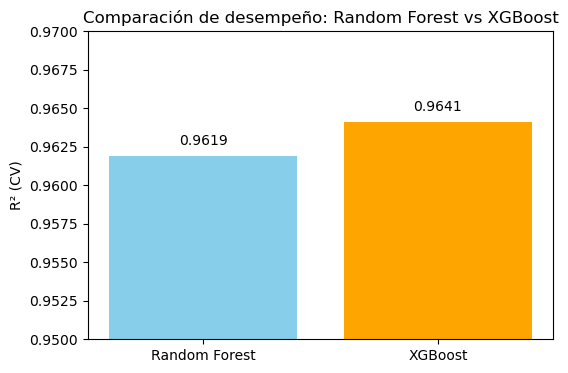

In [9]:
import matplotlib.pyplot as plt

# Datos
modelos = ['Random Forest', 'XGBoost']
r2_scores = [0.9619, 0.9641]

# Crear la gráfica
plt.figure(figsize=(6,4))
bars = plt.bar(modelos, r2_scores, color=['skyblue', 'orange'])
plt.ylim(0.95, 0.97)  # Ajustar límites para ver mejor la diferencia
plt.ylabel('R² (CV)')
plt.title('Comparación de desempeño: Random Forest vs XGBoost')

# Añadir valores encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0005, f'{yval:.4f}', ha='center', va='bottom')

plt.show()


# Justificación de la métrica y resultados de los modelos

## Métrica utilizada: R² (Coeficiente de determinación)

Elegimos la métrica **R²** para evaluar los diferentes modelos de regresión.

En este caso, queremos predecir el **precio de un Toyota** en función de variables como:

- `model` (modelo del auto)  
- `year` (año del vehículo)  
- `transmission` (tipo de transmisión)  
- `mileage` (kilometraje)  
- `fuelType` (tipo de combustible)  
- `tax` (impuesto)  
- `mpg` (consumo de combustible)  
- `engineSize` (cilindrada del motor)

R² es adecuado porque mide **qué proporción de la varianza del precio real es explicada por el modelo**. A diferencia del error absoluto o cuadrático, R² permite:

- Comparar fácilmente modelos de regresión entre sí.  
- Entender cuánto se acerca la predicción del modelo a los valores reales en términos de varianza explicada.  
- Interpretar el desempeño de manera intuitiva:  
  - R² = 1 → modelo explica perfectamente los precios  
  - R² = 0 → el modelo no explica nada de la variabilidad  
  - R² < 0 → el modelo tiene peor desempeño que simplemente predecir la media  

---

## Resultados de los modelos

**Random Forest**  
- Mejor R² (CV): 0.9619  
- El modelo Random Forest logra explicar **el 96.19% de la variabilidad del precio**, lo que indica un ajuste excelente.  
- La capacidad de los árboles para capturar interacciones complejas entre variables como `year`, `mileage` y `engineSize` permite este alto desempeño sin requerir transformación manual de variables.  

**XGBoost**  
- Mejor R² (CV): 0.9641  
- XGBoost obtuvo un desempeño ligeramente superior al Random Forest, explicando **el 96.41% de la variabilidad del precio**.  
- La combinación de boosting y regularización le permite reducir el error residual y manejar relaciones no lineales de manera más eficiente que un Random Forest estándar.  

---

## Interpretación general

- Ambos modelos muestran un **rendimiento sobresaliente**, con R² por encima de 0.96.  
- La diferencia entre XGBoost y Random Forest es mínima, pero XGBoost logra capturar ligeramente mejor la variabilidad del precio, lo que puede ser útil para predicciones más precisas.  
- R² es especialmente útil aquí porque:  
  1. Permite comparar de forma directa cómo cada modelo explica la variabilidad de los precios.  
  2. Es interpretable y comunica claramente la capacidad predictiva a stakeholders.  
  3. Es robusto frente a escalas de precio diferentes y facilita identificar modelos que generalicen bien.  

**Conclusión:**  
XGBoost se posiciona como el modelo más adecuado, ofreciendo la mejor capacidad predictiva, mientras que Random Forest sigue siendo una alternativa sólida con menor complejidad computacional.


<div style="background-color: #cce5ff; padding: 15px; border-radius: 8px;">
  <h3> Conclusión</h3>
</div>


El presente proyecto cumplió con el objetivo general de analizar y predecir el precio de vehículos Toyota a partir de características del automóvil, mediante la aplicación de distintos modelos de regresión supervisada. A partir del dataset disponible, se realizó un proceso de limpieza, transformación y selección de variables, considerando atributos clave como model, year, transmission, mileage, fuelType, tax, mpg y engineSize, asegurando que los datos estuvieran listos para la modelación predictiva.

En relación con los objetivos específicos, se construyeron y ajustaron dos modelos principales: Random Forest y XGBoost. Cada modelo fue entrenado con un proceso de optimización de hiperparámetros y evaluado mediante validación cruzada de 5 particiones (k-fold cross-validation), utilizando R² (coeficiente de determinación) como métrica principal. La elección de esta métrica fue acertada, ya que permite cuantificar de manera directa qué proporción de la variabilidad del precio es explicada por cada modelo, ofreciendo una medida interpretable del poder predictivo de los algoritmos.

Los resultados mostraron que el modelo XGBoost alcanzó el mejor desempeño general, con un R² promedio de 0.9641, indicando una excelente capacidad para explicar la variabilidad de los precios y mantener estabilidad entre los pliegues de validación. Random Forest obtuvo un desempeño muy cercano, con un R² promedio de 0.9619, destacando por su solidez y capacidad de capturar relaciones complejas entre las variables sin requerir transformaciones extensas.

En términos de análisis e interpretación, los resultados confirman que atributos como el año del vehículo, el kilometraje, el tamaño del motor y el tipo de transmisión contienen información predictiva significativa sobre el precio. La alta performance de ambos modelos refleja que es posible modelar con precisión los precios de los autos utilizando variables fácilmente accesibles, facilitando decisiones informadas tanto para compradores como para vendedores.

Finalmente, se concluye que XGBoost representa la mejor opción para el caso analizado, al ofrecer un equilibrio óptimo entre precisión y capacidad de generalización, mientras que Random Forest se mantiene como una alternativa sólida y confiable, especialmente cuando se busca un modelo menos sensible a ajustes finos de hiperparámetros. El proyecto demuestra que, mediante técnicas adecuadas de preprocesamiento, validación y optimización, es posible desarrollar modelos predictivos confiables que aporten información valiosa para la estimación de precios de automóviles, contribuyendo a una mejor toma de decisiones en el mercado automotor.

<div style="background-color: #cce5ff; padding: 15px; border-radius: 8px;">
  <h3> Referencias</h3>
</div>


- Anassarfraz13. (s. f.). Toyota Used Car Market Insights [Data set]. Kaggle. https://www.kaggle.com/datasets/anassarfraz13/toyota-used-car-market-insights
